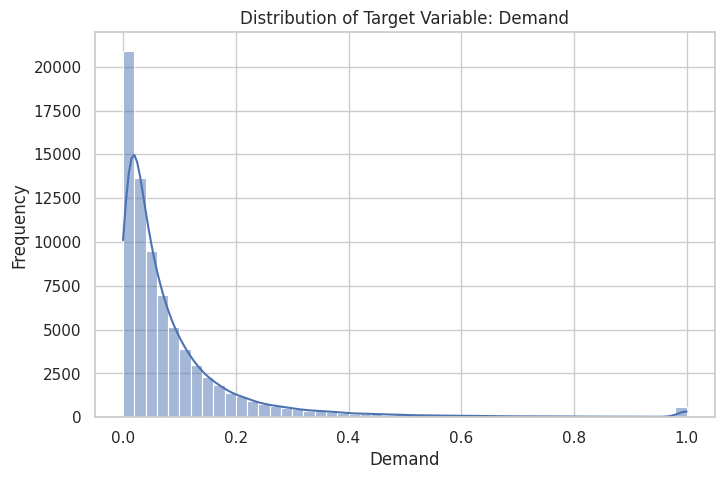

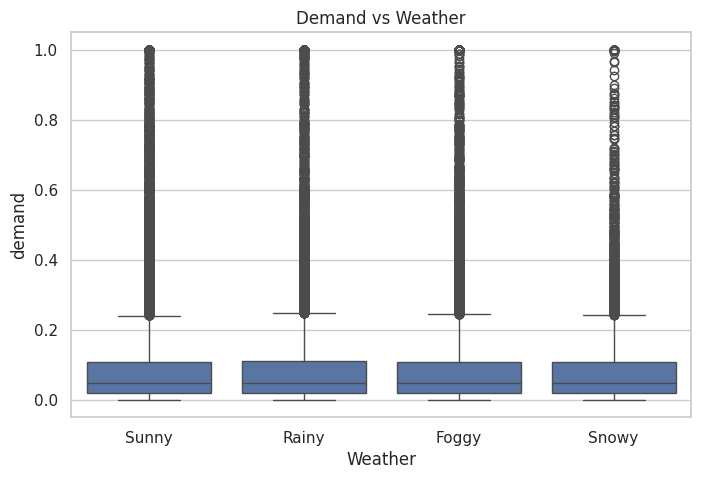

Training LightGBM...
LightGBM 5-Fold Mean R² Score: 0.85354

Training XGBoost...
XGBoost 5-Fold Mean R² Score: 0.85587

Training CatBoost...
CatBoost 5-Fold Mean R² Score: 0.82513

Training RandomForest...
RandomForest 5-Fold Mean R² Score: 0.86696

--- Model Performance Summary ---
LightGBM: 0.85354
XGBoost: 0.85587
CatBoost: 0.82513
RandomForest: 0.86696

Best Model Selected: RandomForest

Final submission saved to 'submission.csv'


In [3]:
# ==============================================================================
# 1. IMPORT LIBRARIES
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

# Machine Learning Models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ==============================================================================
# 2. LOAD DATASETS
# ==============================================================================
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')

# ==============================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================
# Plot distribution of the target variable
plt.figure(figsize=(8, 5))
sns.histplot(train['demand'], bins=50, kde=True)
plt.title('Distribution of Target Variable: Demand')
plt.xlabel('Demand')
plt.ylabel('Frequency')
plt.show()

# Boxplot of demand across different weather conditions
plt.figure(figsize=(8, 5))
sns.boxplot(data=train, x='Weather', y='demand')
plt.title('Demand vs Weather')
plt.show()

# ==============================================================================
# 4. PREPROCESSING & FEATURE ENGINEERING
# ==============================================================================
# Combine train and test for consistent preprocessing
train['is_train'] = 1
test['is_train'] = 0
test['demand'] = np.nan
df = pd.concat([train, test], axis=0).reset_index(drop=True)

# A. Handle Missing Values
# Categorical features: Impute with the mode
df['RoadType'] = df['RoadType'].fillna(df['RoadType'].mode()[0])
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])

# Numerical feature (Temperature): Impute with median to be robust to outliers
df['Temperature'] = df['Temperature'].fillna(df['Temperature'].median())

# B. Timestamp Parsing (HH:MM to Continuous/Cyclic Values)
df[['Hour', 'Minute']] = df['timestamp'].str.split(':', expand=True).astype(int)
df['TimeOfDay_Minutes'] = df['Hour'] * 60 + df['Minute']

# Cyclic transformations (Sin/Cos) to capture temporal cyclicality (24h = 1440 min)
df['sin_time'] = np.sin(2 * np.pi * df['TimeOfDay_Minutes'] / 1440.0)
df['cos_time'] = np.cos(2 * np.pi * df['TimeOfDay_Minutes'] / 1440.0)

# C. Geohash Feature Extraction
# Extract the first few characters of the geohash to group nearby locations
df['geo_1'] = df['geohash'].str[0:2]
df['geo_2'] = df['geohash'].str[0:3]
df['geo_3'] = df['geohash'].str[0:4]

# D. Label Encoding for Categorical Variables
cat_cols = ['geohash', 'geo_1', 'geo_2', 'geo_3', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Drop unused columns
df = df.drop(columns=['timestamp', 'Hour', 'Minute'])

# Split back to Train and Test
X_train_full = df[df['is_train'] == 1].drop(columns=['is_train', 'demand'])
y_train_full = df[df['is_train'] == 1]['demand']
X_test = df[df['is_train'] == 0].drop(columns=['is_train', 'demand'])

# ==============================================================================
# 5. MODEL TRAINING & EVALUATION (5-FOLD CROSS-VALIDATION)
# ==============================================================================
# Initialize regressors
models = {
    'LightGBM': LGBMRegressor(random_state=42, n_estimators=300, learning_rate=0.05, verbose=-1),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=300, learning_rate=0.05, max_depth=6),
    'CatBoost': CatBoostRegressor(random_state=42, iterations=300, learning_rate=0.05, verbose=0),
    'RandomForest': RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10, n_jobs=-1)
}

results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    print(f"Training {model_name}...")
    cv_scores = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_full, y_train_full)):
        X_tr, y_tr = X_train_full.iloc[train_idx], y_train_full.iloc[train_idx]
        X_va, y_va = X_train_full.iloc[val_idx], y_train_full.iloc[val_idx]

        # Train
        model.fit(X_tr, y_tr)

        # Predict & Evaluate
        preds = model.predict(X_va)
        score = r2_score(y_va, preds)
        cv_scores.append(score)

    mean_r2 = np.mean(cv_scores)
    results[model_name] = mean_r2
    print(f"{model_name} 5-Fold Mean R² Score: {mean_r2:.5f}\n")

# ==============================================================================
# 6. MODEL SELECTION & PREDICTION ON TEST SET
# ==============================================================================
print("--- Model Performance Summary ---")
for name, score in results.items():
    print(f"{name}: {score:.5f}")

best_model_name = max(results, key=results.get)
print(f"\nBest Model Selected: {best_model_name}")

# Retrain the best model on the entire training dataset
best_model = models[best_model_name]
best_model.fit(X_train_full, y_train_full)

# Generate predictions for the Test set
test_predictions = best_model.predict(X_test)

# Prevent negative demand values
test_predictions = np.clip(test_predictions, a_min=0.0, a_max=None)

# ==============================================================================
# 7. CREATE SUBMISSION FILE
# ==============================================================================
# Ensure the Index aligns with X_test index
submission = pd.DataFrame({
    'Index': X_test['Index'],
    'demand': test_predictions
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("\nFinal submission saved to 'submission.csv'")

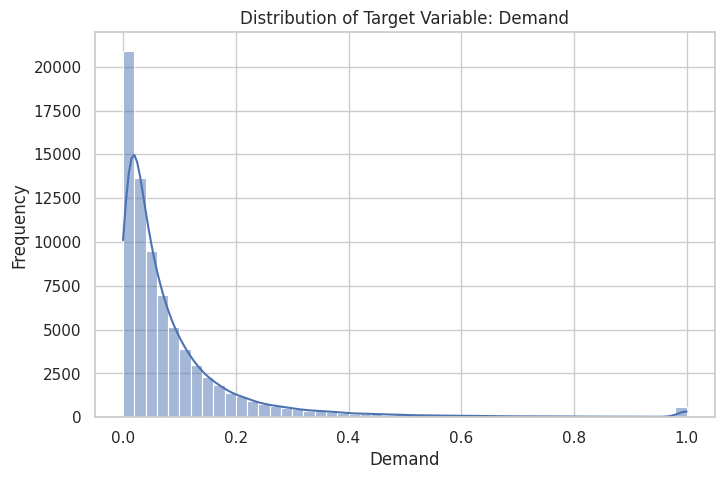

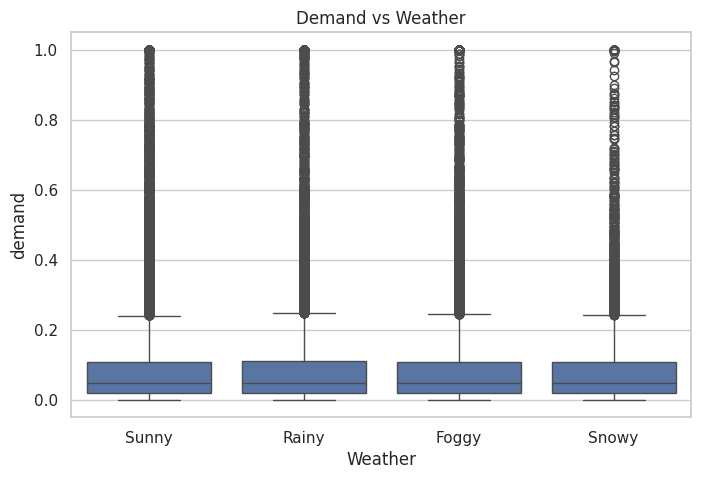

Training LightGBM...
LightGBM 5-Fold Mean R² Score: 0.85354

Training XGBoost...
XGBoost 5-Fold Mean R² Score: 0.85587

Training CatBoost...
CatBoost 5-Fold Mean R² Score: 0.82513

Training RandomForest...
RandomForest 5-Fold Mean R² Score: 0.86696

--- Model Performance Summary ---
LightGBM: 0.85354
XGBoost: 0.85587
CatBoost: 0.82513
RandomForest: 0.86696

Best Model Selected: RandomForest

Final submission saved to 'submission.csv'


In [4]:
# ==============================================================================
# 1. IMPORT LIBRARIES
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

# Machine Learning Models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ==============================================================================
# 2. LOAD DATASETS
# ==============================================================================
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')

# ==============================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================
# Plot distribution of the target variable
plt.figure(figsize=(8, 5))
sns.histplot(train['demand'], bins=50, kde=True)
plt.title('Distribution of Target Variable: Demand')
plt.xlabel('Demand')
plt.ylabel('Frequency')
plt.show()

# Boxplot of demand across different weather conditions
plt.figure(figsize=(8, 5))
sns.boxplot(data=train, x='Weather', y='demand')
plt.title('Demand vs Weather')
plt.show()

# ==============================================================================
# 4. PREPROCESSING & FEATURE ENGINEERING
# ==============================================================================
# Combine train and test for consistent preprocessing
train['is_train'] = 1
test['is_train'] = 0
test['demand'] = np.nan
df = pd.concat([train, test], axis=0).reset_index(drop=True)

# A. Handle Missing Values
# Categorical features: Impute with the mode
df['RoadType'] = df['RoadType'].fillna(df['RoadType'].mode()[0])
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])

# Numerical feature (Temperature): Impute with median to be robust to outliers
df['Temperature'] = df['Temperature'].fillna(df['Temperature'].median())

# B. Timestamp Parsing (HH:MM to Continuous/Cyclic Values)
df[['Hour', 'Minute']] = df['timestamp'].str.split(':', expand=True).astype(int)
df['TimeOfDay_Minutes'] = df['Hour'] * 60 + df['Minute']

# Cyclic transformations (Sin/Cos) to capture temporal cyclicality (24h = 1440 min)
df['sin_time'] = np.sin(2 * np.pi * df['TimeOfDay_Minutes'] / 1440.0)
df['cos_time'] = np.cos(2 * np.pi * df['TimeOfDay_Minutes'] / 1440.0)

# C. Geohash Feature Extraction
# Extract the first few characters of the geohash to group nearby locations
df['geo_1'] = df['geohash'].str[0:2]
df['geo_2'] = df['geohash'].str[0:3]
df['geo_3'] = df['geohash'].str[0:4]

# D. Label Encoding for Categorical Variables
cat_cols = ['geohash', 'geo_1', 'geo_2', 'geo_3', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Drop unused columns
df = df.drop(columns=['timestamp', 'Hour', 'Minute'])

# Split back to Train and Test
X_train_full = df[df['is_train'] == 1].drop(columns=['is_train', 'demand'])
y_train_full = df[df['is_train'] == 1]['demand']
X_test = df[df['is_train'] == 0].drop(columns=['is_train', 'demand'])

# ==============================================================================
# 5. MODEL TRAINING & EVALUATION (5-FOLD CROSS-VALIDATION)
# ==============================================================================
# Initialize regressors
models = {
    'LightGBM': LGBMRegressor(random_state=42, n_estimators=300, learning_rate=0.05, verbose=-1),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=300, learning_rate=0.05, max_depth=6),
    'CatBoost': CatBoostRegressor(random_state=42, iterations=300, learning_rate=0.05, verbose=0),
    'RandomForest': RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10, n_jobs=-1)
}

results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    print(f"Training {model_name}...")
    cv_scores = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_full, y_train_full)):
        X_tr, y_tr = X_train_full.iloc[train_idx], y_train_full.iloc[train_idx]
        X_va, y_va = X_train_full.iloc[val_idx], y_train_full.iloc[val_idx]

        # Train
        model.fit(X_tr, y_tr)

        # Predict & Evaluate
        preds = model.predict(X_va)
        score = r2_score(y_va, preds)
        cv_scores.append(score)

    mean_r2 = np.mean(cv_scores)
    results[model_name] = mean_r2
    print(f"{model_name} 5-Fold Mean R² Score: {mean_r2:.5f}\n")

# ==============================================================================
# 6. MODEL SELECTION & PREDICTION ON TEST SET
# ==============================================================================
print("--- Model Performance Summary ---")
for name, score in results.items():
    print(f"{name}: {score:.5f}")

best_model_name = max(results, key=results.get)
print(f"\nBest Model Selected: {best_model_name}")

# Retrain the best model on the entire training dataset
best_model = models[best_model_name]
best_model.fit(X_train_full, y_train_full)

# Generate predictions for the Test set
test_predictions = best_model.predict(X_test)

# Prevent negative demand values
test_predictions = np.clip(test_predictions, a_min=0.0, a_max=None)

# ==============================================================================
# 7. CREATE SUBMISSION FILE
# ==============================================================================
# Ensure the Index aligns with X_test index
submission = pd.DataFrame({
    'Index': X_test['Index'],
    'demand': test_predictions
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("\nFinal submission saved to 'submission.csv'")

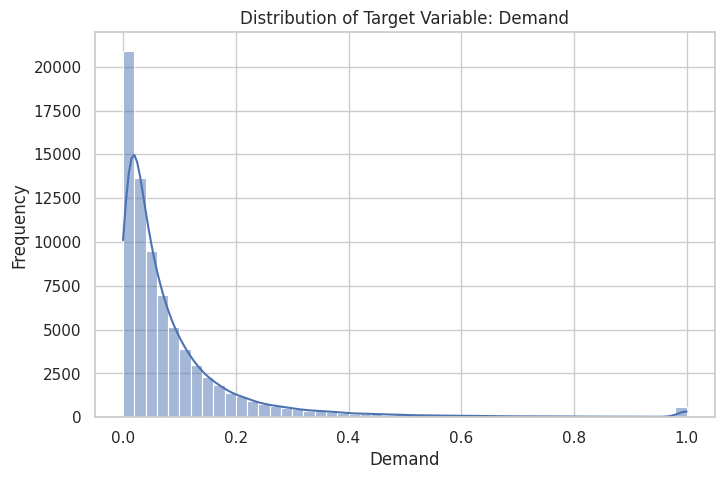

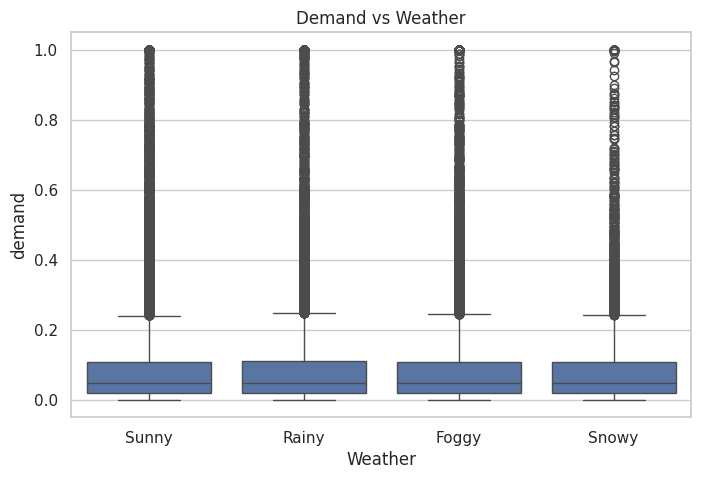

Training LightGBM...
LightGBM 5-Fold Mean R² Score: 0.85270

Training XGBoost...
XGBoost 5-Fold Mean R² Score: 0.85627

Training CatBoost...
CatBoost 5-Fold Mean R² Score: 0.82472

Training RandomForest...
RandomForest 5-Fold Mean R² Score: 0.86697

--- Model Performance Summary ---
LightGBM: 0.85270
XGBoost: 0.85627
CatBoost: 0.82472
RandomForest: 0.86697

Best Model Selected: RandomForest

Final submission saved to 'submission.csv'
Submission shape verified: (41778, 2)


In [5]:
# ==============================================================================
# 1. IMPORT LIBRARIES
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

# Machine Learning Models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ==============================================================================
# 2. LOAD DATASETS (Fix: Added /content/ paths)
# ==============================================================================
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')
sample_sub = pd.read_csv('/content/sample_submission.csv')

# ==============================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================
# Plot distribution of the target variable
plt.figure(figsize=(8, 5))
sns.histplot(train['demand'], bins=50, kde=True)
plt.title('Distribution of Target Variable: Demand')
plt.xlabel('Demand')
plt.ylabel('Frequency')
plt.show()

# Boxplot of demand across different weather conditions
plt.figure(figsize=(8, 5))
sns.boxplot(data=train, x='Weather', y='demand')
plt.title('Demand vs Weather')
plt.show()

# ==============================================================================
# 4. PREPROCESSING & FEATURE ENGINEERING
# ==============================================================================
# Combine train and test for consistent preprocessing
train['is_train'] = 1
test['is_train'] = 0
test['demand'] = np.nan
df = pd.concat([train, test], axis=0).reset_index(drop=True)

# A. Handle Missing Values
df['RoadType'] = df['RoadType'].fillna(df['RoadType'].mode()[0])
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])
df['Temperature'] = df['Temperature'].fillna(df['Temperature'].median())

# B. Timestamp Parsing (HH:MM to Continuous/Cyclic Values)
df[['Hour', 'Minute']] = df['timestamp'].str.split(':', expand=True).astype(int)
df['TimeOfDay_Minutes'] = df['Hour'] * 60 + df['Minute']

# Cyclic transformations (Sin/Cos)
df['sin_time'] = np.sin(2 * np.pi * df['TimeOfDay_Minutes'] / 1440.0)
df['cos_time'] = np.cos(2 * np.pi * df['TimeOfDay_Minutes'] / 1440.0)

# C. Geohash Feature Extraction
df['geo_1'] = df['geohash'].str[0:2]
df['geo_2'] = df['geohash'].str[0:3]
df['geo_3'] = df['geohash'].str[0:4]

# D. Label Encoding for Categorical Variables
cat_cols = ['geohash', 'geo_1', 'geo_2', 'geo_3', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Keep track of 'Index' for final submission before dropping it from features
test_indices = df[df['is_train'] == 0]['Index'].values

# Drop unused and identifier columns (Fix: Dropping 'Index' from features)
df = df.drop(columns=['timestamp', 'Hour', 'Minute', 'Index'])

# Split back to Train and Test
X_train_full = df[df['is_train'] == 1].drop(columns=['is_train', 'demand'])
y_train_full = df[df['is_train'] == 1]['demand']
X_test = df[df['is_train'] == 0].drop(columns=['is_train', 'demand'])

# ==============================================================================
# 5. MODEL TRAINING & EVALUATION (5-FOLD CROSS-VALIDATION)
# ==============================================================================
models = {
    'LightGBM': LGBMRegressor(random_state=42, n_estimators=300, learning_rate=0.05, verbose=-1),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=300, learning_rate=0.05, max_depth=6),
    'CatBoost': CatBoostRegressor(random_state=42, iterations=300, learning_rate=0.05, verbose=0),
    'RandomForest': RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10, n_jobs=-1)
}

results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    print(f"Training {model_name}...")
    cv_scores = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_full, y_train_full)):
        X_tr, y_tr = X_train_full.iloc[train_idx], y_train_full.iloc[train_idx]
        X_va, y_va = X_train_full.iloc[val_idx], y_train_full.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_va)
        score = r2_score(y_va, preds)
        cv_scores.append(score)

    mean_r2 = np.mean(cv_scores)
    results[model_name] = mean_r2
    print(f"{model_name} 5-Fold Mean R² Score: {mean_r2:.5f}\n")

# ==============================================================================
# 6. MODEL SELECTION & PREDICTION ON TEST SET
# ==============================================================================
print("--- Model Performance Summary ---")
for name, score in results.items():
    print(f"{name}: {score:.5f}")

best_model_name = max(results, key=results.get)
print(f"\nBest Model Selected: {best_model_name}")

best_model = models[best_model_name]
best_model.fit(X_train_full, y_train_full)

test_predictions = best_model.predict(X_test)
test_predictions = np.clip(test_predictions, a_min=0.0, a_max=None)

# ==============================================================================
# 7. CREATE SUBMISSION FILE (Fix: Using preserved test_indices)
# ==============================================================================
submission = pd.DataFrame({
    'Index': test_indices,
    'demand': test_predictions
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("\nFinal submission saved to 'submission.csv'")
print(f"Submission shape verified: {submission.shape}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')